In [188]:
import pandas as pd
import yfinance as yf
import datetime as dt
from curl_cffi import requests
import numpy as np

In [ ]:
session = requests.Session(impersonate='chrome')
end_date = dt.datetime(2025, 5, 9)
start_date = end_date - dt.timedelta(days=365)
symbol_names = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies#S&P_500_component_stocks')
names = symbol_names[0]['Symbol'].str.replace('.','-').to_list()

In [26]:
df3 = yf.download(tickers = names, start=start_date, end=end_date )

[*********************100%***********************]  503 of 503 completed


In [ ]:
stocklist = ['AAPL', 'TSLA', 'NVDA','META', 'GOOGL', 'AMZN', 'MSFT']
MAG7 = ClosingPrice[stocklist].copy()
Indices_Names = ['^GSPC', '^IXIC', 'VGT']
Indices = yf.download(tickers = Indices_Names, start = start_date, end = end_date, session=session)
Indices_Closing = Indices['Close']

[*********************100%***********************]  3 of 3 completed


In [151]:
# S&P 500 Stocks
ClosingPrice = df3['Close'].copy()
High = df3['High'].copy()
Low = df3['Low'].copy()
Volume = df3['Volume'].copy()
Open = df3['Open'].copy()
#Indices Group
Indices_Closing = Indices['Close'].copy()
Indices_High = Indices['High'].copy()
Indices_Low = Indices['Low'].copy()
Indices_Volume = Indices['Volume'].copy()
Indices_Open = Indices['Open'].copy()


In [234]:
df = pd.concat([MAG7, Indices_Closing], axis = 1).pct_change() * 100 
df.columns = ['Apple', 'Tesla', 'NVIDIA', 'Meta', 'Alphabet', 'Amazon', 'Microsoft', 'Vanguard_Tech', 'SP500', 'NASDAQ']
df = df.dropna()

In [189]:
df4 = df3.stack()
df4.index.names = ['Date', 'Ticker']

C:\Users\Phillip\AppData\Local\Temp\ipykernel_31256\4001919478.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df4 = df3.stack()


## GARCH

In [206]:
import seaborn as sns
import math
import matplotlib.pyplot as plt
from tabulate import tabulate

%matplotlib inline
sns.set_style(style = 'darkgrid')

Text(0.5, 1.0, 'Daily Returns of S&P 500')

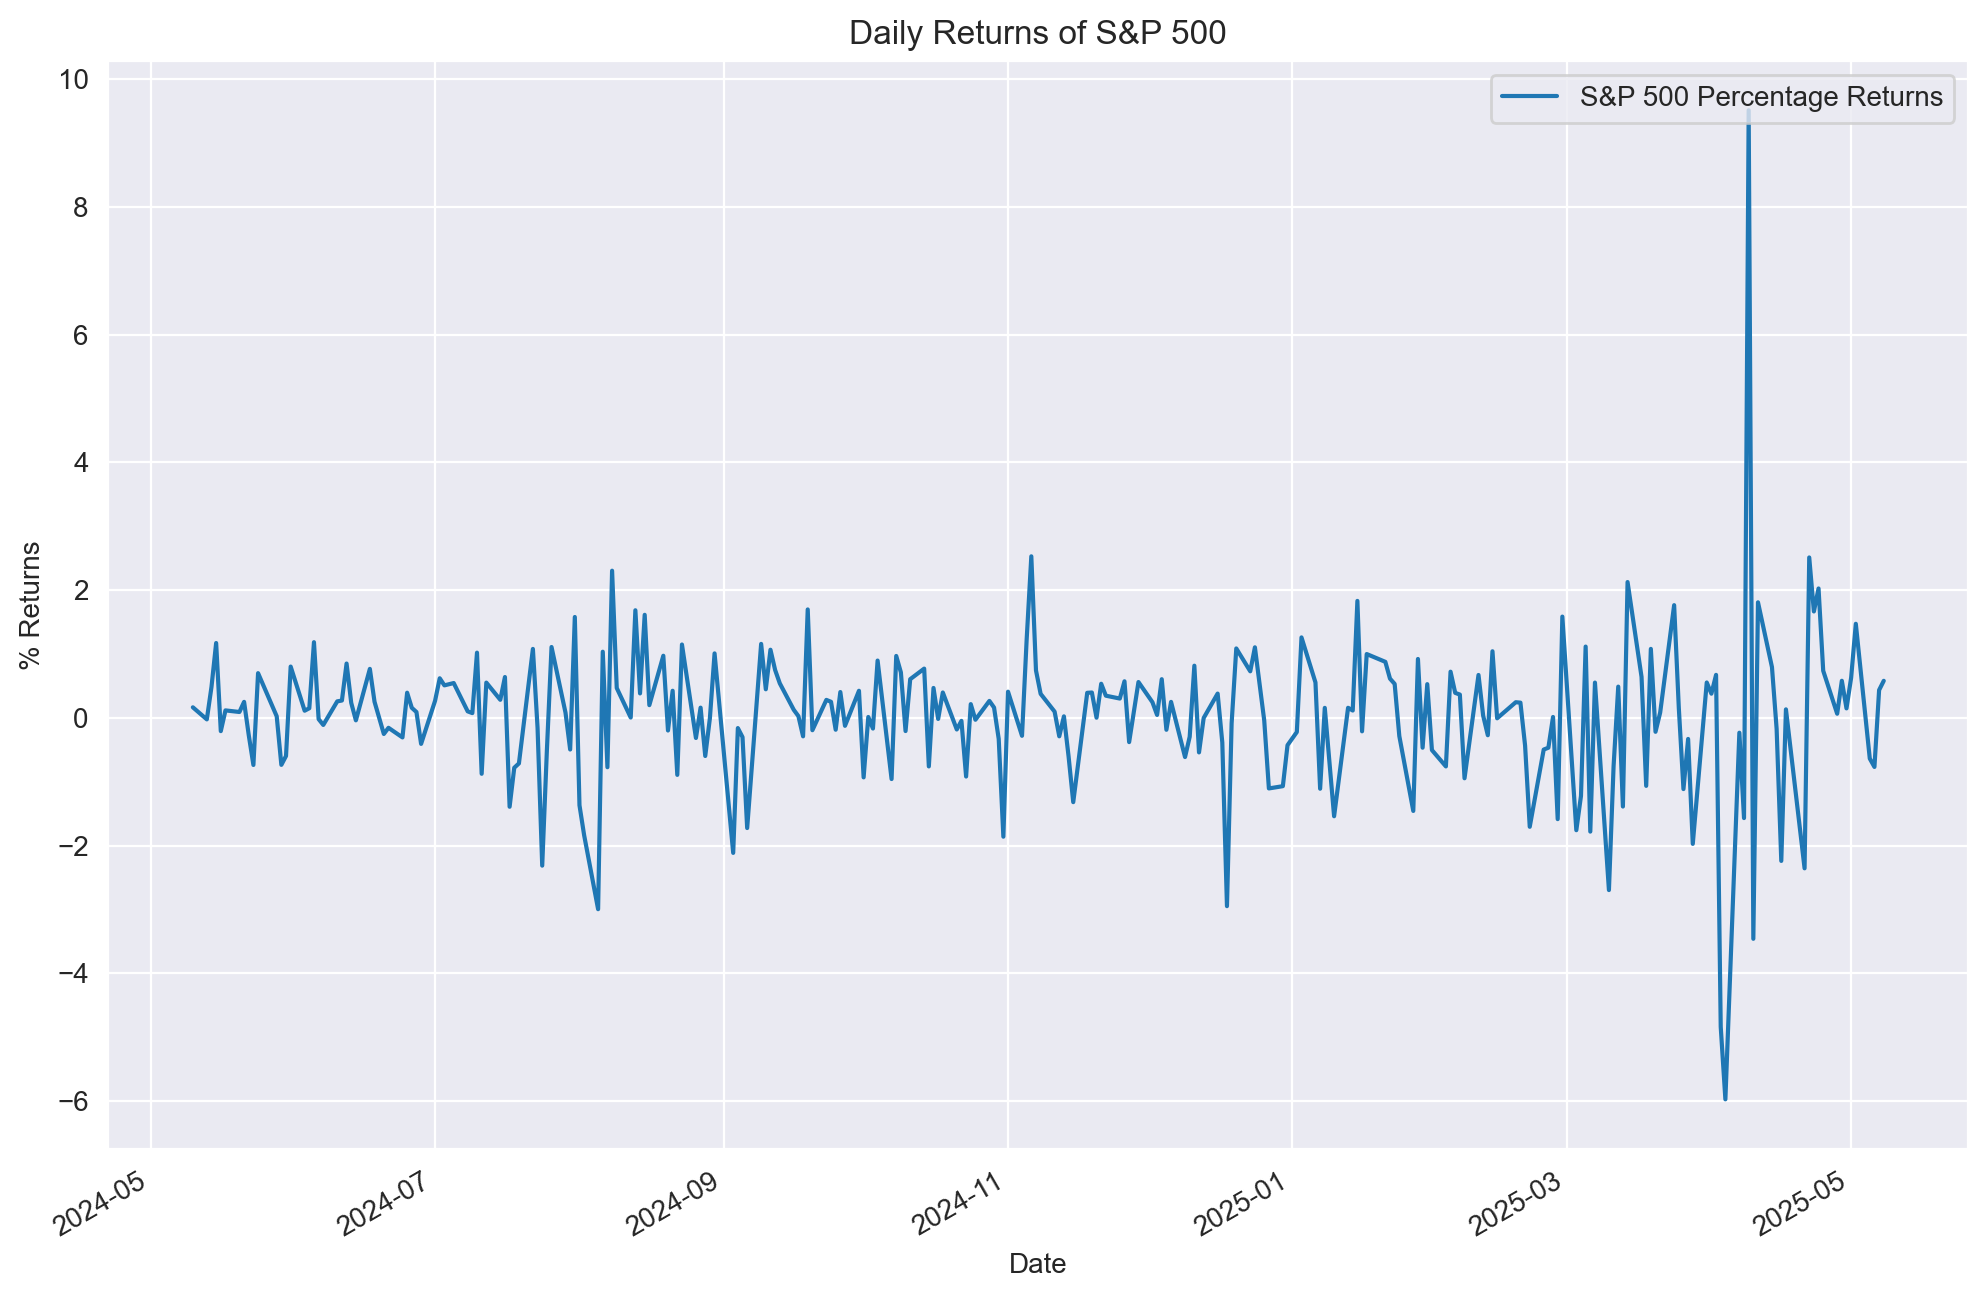

In [235]:
fig, ax = plt.subplots(figsize=(12, 8))
plt.plot(df['SP500'], label = 'S&P 500 Percentage Returns')
plt.legend(loc='upper right')
plt.xlabel('Date')
plt.ylabel('% Returns')
plt.gcf().autofmt_xdate()
%config InlineBackend.figure_format = 'retina'
plt.title('Daily Returns of S&P 500')

In [236]:
#Calculating Daily, Monthly, Yearly Volatilities
daily_vol_SP = df['SP500'].std()
monthly_vol_SP = daily_vol_SP * math.sqrt(21)
annual_vol_SP = daily_vol_SP * math.sqrt(252)
#Tabulate
print(tabulate([['SP 500', daily_vol_SP, monthly_vol_SP, annual_vol_SP]],
                headers = ['Daily Volatility %', 'Monthly Volatility %', 'Annual Volatility %'],
                tablefmt = 'fancy_grid',
                stralign='center',
                numalign='center',
                floatfmt=".2f"))

╒════════╤══════════════════════╤════════════════════════╤═══════════════════════╕
│        │  Daily Volatility %  │  Monthly Volatility %  │  Annual Volatility %  │
╞════════╪══════════════════════╪════════════════════════╪═══════════════════════╡
│ SP 500 │         1.22         │          5.61          │         19.44         │
╘════════╧══════════════════════╧════════════════════════╧═══════════════════════╛


In [ ]:
from arch import arch_model
from arch.__future__ import reindexing

In [239]:

garch_model_SP = arch_model(df['SP500'], p = 1, q = 1,
                            mean = 'constant', vol = 'GARCH',
                            dist='normal')

garch_sp_result = garch_model_SP.fit(disp='off')
print(garch_sp_result.params)

mu          0.078807
omega       0.083514
alpha[1]    0.199214
beta[1]     0.750426
Name: params, dtype: float64


In [240]:
#Forecasting using Fitted GARCH
garch_sp_forecast = garch_sp_result.forecast(horizon = 5)
print(garch_sp_forecast.variance[-1:])

                 h.1       h.2       h.3       h.4       h.5
Date                                                        
2025-05-08  0.911094  0.948725  0.984462  1.018399  1.050626


In [276]:
#Fitting GARCH Model
rolling_predictions_SP = []
testing_size = len(df['SP500'])

for i in range(testing_size):
    training = df['SP500'][:(testing_size-i)]
    model = arch_model(training, mean = 'Zero', p = 1, q = 1, rescale = False)
    model_fit = model.fit(disp='off')
    pred = model_fit.forecast(horizon = 1)
    rolling_predictions_SP.append(np.sqrt(pred.variance.values[-1, :][0]))

rolling_predictions_SP = pd.Series(rolling_predictions_SP, index = df['SP500'].index[-testing_size:])

Text(0.5, 1.0, 'Rolling Predictions')

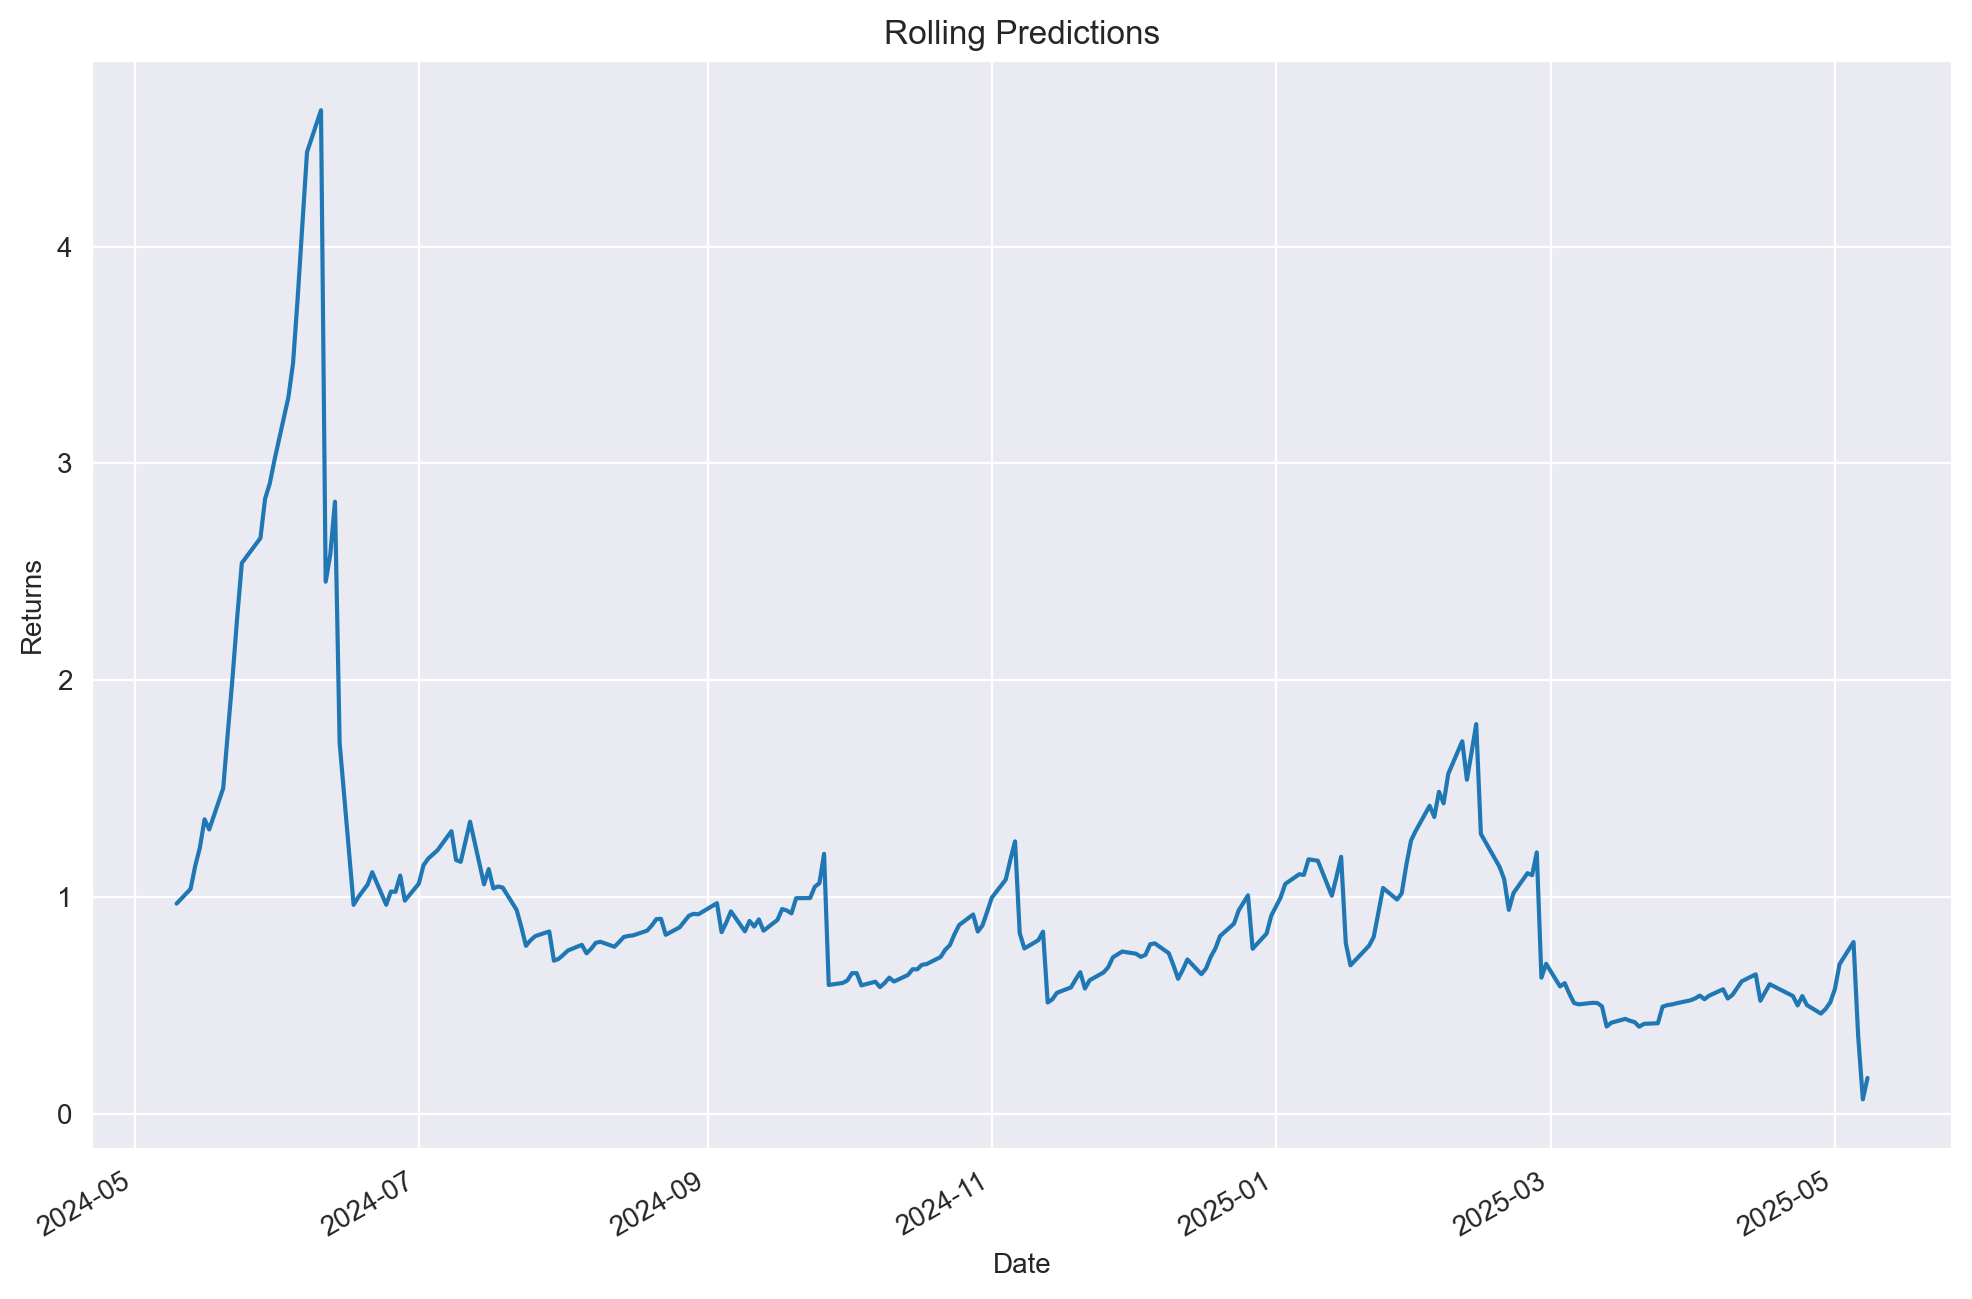

In [277]:
fig, ax = plt.subplots(figsize = (12,8))
plt.xlabel('Date')
plt.ylabel('Returns')
plt.gcf().autofmt_xdate()
plt.plot(rolling_predictions_SP)
plt.title('Rolling Predictions')

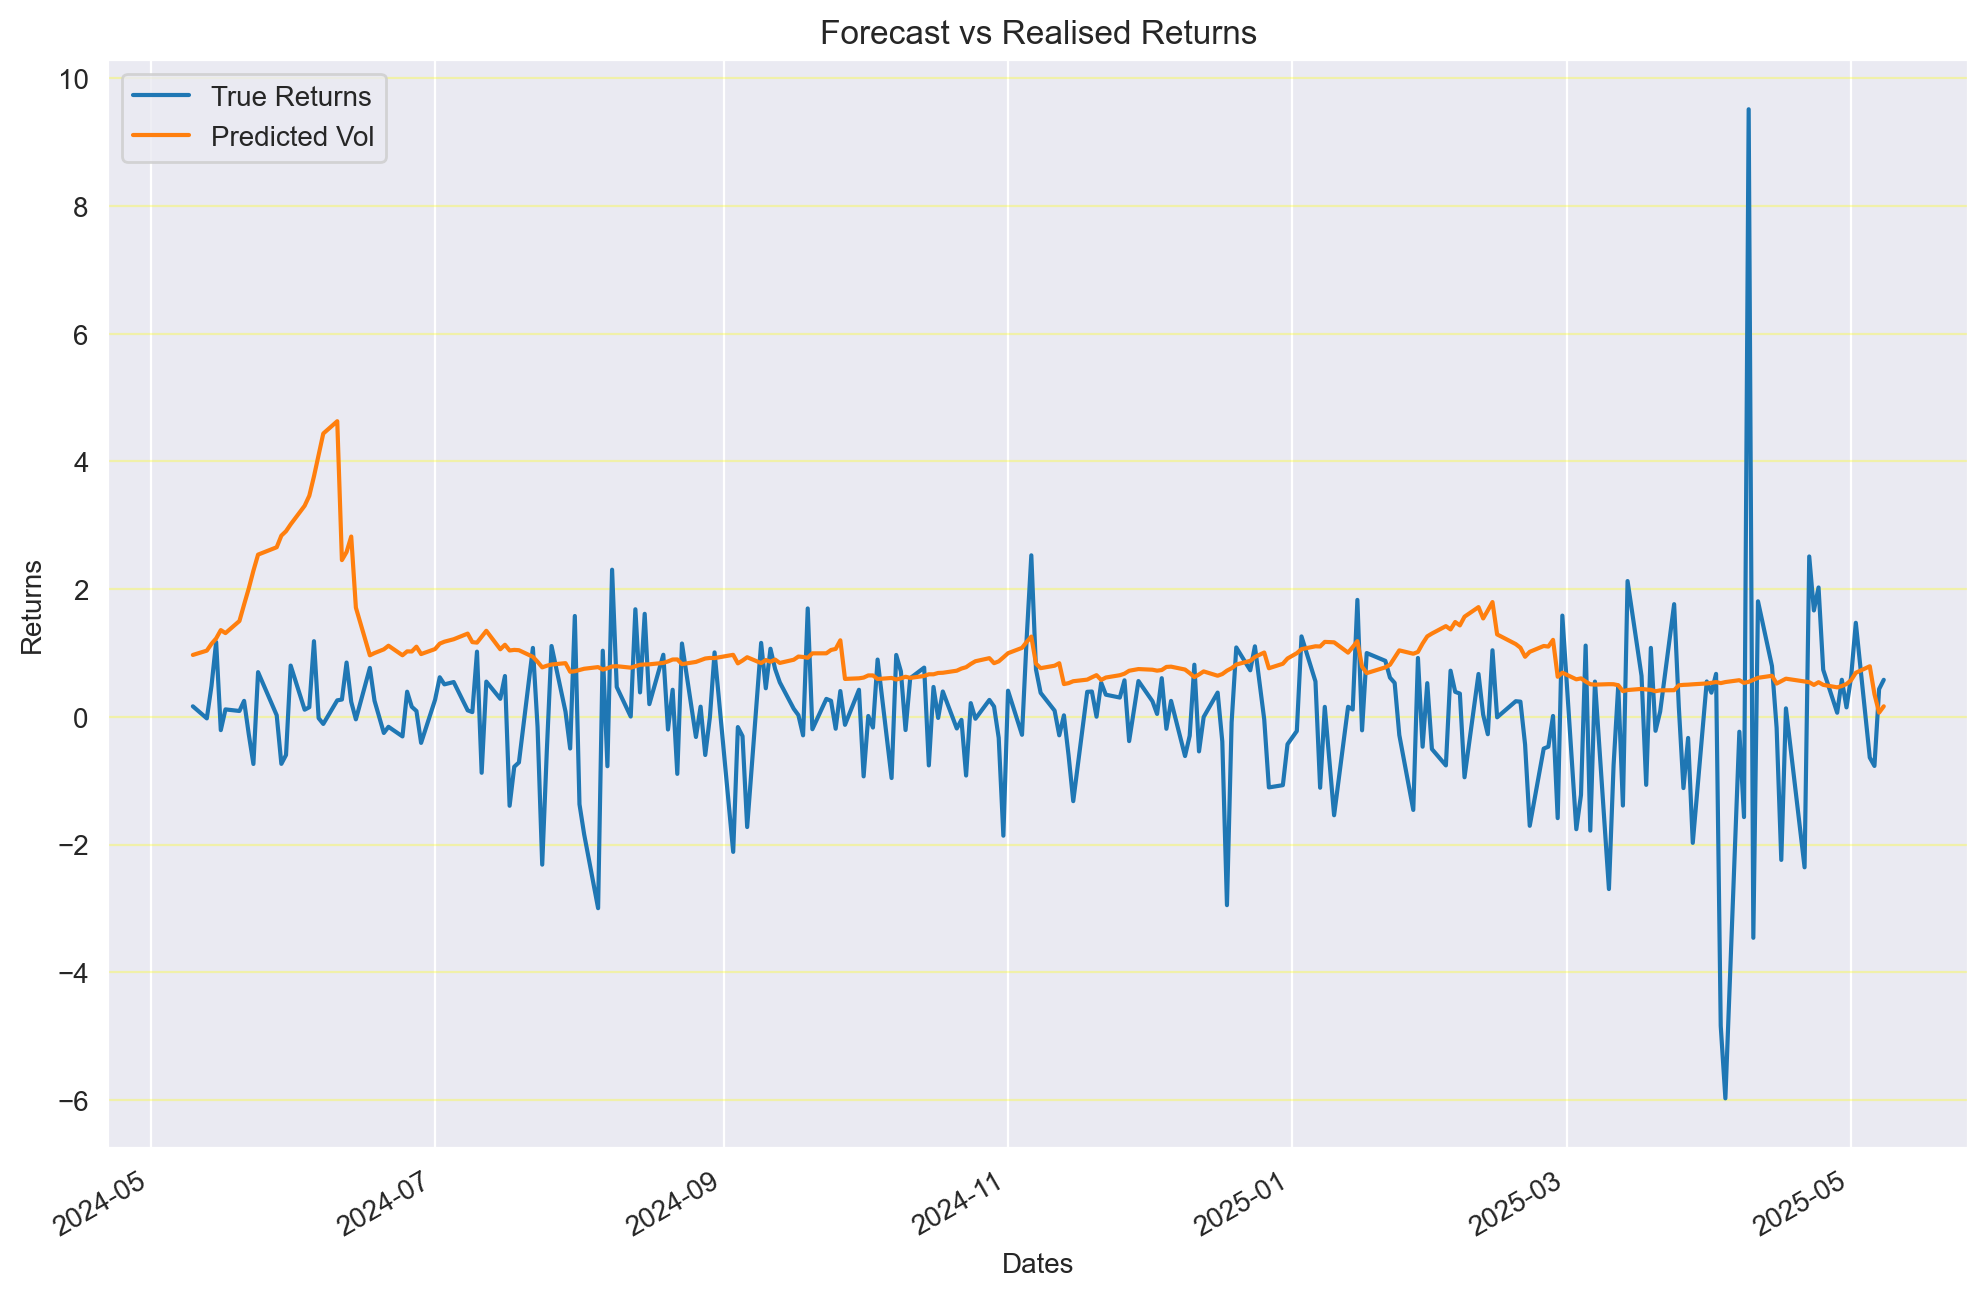

In [278]:
#Model Check
fig, ax = plt.subplots(figsize=(12,8))
ax.grid(which = 'major', axis = 'y', color='yellow', alpha = 0.3, zorder=1)
plt.plot(df['SP500'][-(testing_size):])
plt.plot(rolling_predictions_SP)
plt.xlabel('Dates')
plt.ylabel('Returns')
plt.gcf().autofmt_xdate()
plt.title('Forecast vs Realised Returns')
plt.legend(['True Returns', 'Predicted Vol'])

In [289]:
def model_evaluation(data : pd.Series,
                     mean = 'Zero',
                     p = 1, 
                     q = 1,
                     vol = 'GARCH'
                     ):
    #Fitting GARCH Model
    am = arch_model(data.dropna(), mean = mean, p = p, q =q, vol = vol)
    res = am.fit(disp='off')

    #Calculate AIC and BIC scores
    aic = res.aic
    bic = res.bic

    #Backtesting
    residuals = data - res.conditional_volatility
    res_t = residuals / res.conditional_volatility
    backtest = (res_t ** 2).sum()

    #OoS Testing
    data_length = len(data)
    train_size = int(0.8 * data_length)
    train_data = data[:train_size]
    test_data = data[train_size:]

    res_oos = am.fit(last_obs= train_data.index[-1], disp = 'off')
    forecast = res_oos.forecast(start = train_data.index[-1],
                                horizon=len(test_data))
    
    #OoS Errors
    forecast_vol = forecast.residual_variance.iloc[-1, :]
    error = (test_data - forecast_vol).dropna()

    return aic, bic, backtest, error, forecast

print(model_evaluation(df['SP500'])[0:3])

(709.0351260988887, np.float64(719.5874847882828), np.float64(481.8237807956932))


In [290]:
forecast = model_evaluation(df['SP500'])[4]

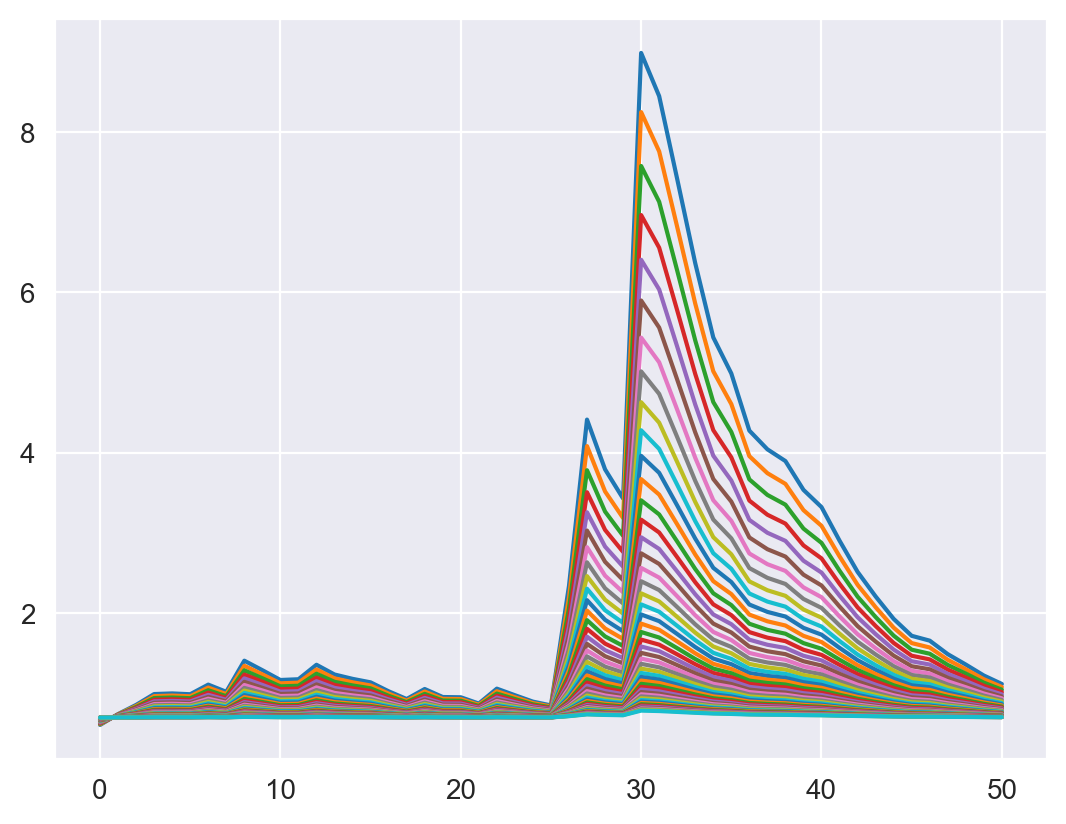

In [297]:
plt.plot(forecast.variance.values)